<a href="https://colab.research.google.com/github/zhangshutao932/StrataScratch-Beer-Data-Analysis/blob/main/Beer_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("BeerDataScienceProject.tar.bz2", compression='bz2', sep=',')

In [4]:
df.shape

(528870, 13)

In [5]:
df.head()

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time
0,5.0,47986,10325,Sausa Weizen,Hefeweizen,2.5,2.0,1.5,1.5,stcules,1.5,A lot of foam. But a lot. In the smell some ba...,1234817823
1,6.2,48213,10325,Red Moon,English Strong Ale,3.0,2.5,3.0,3.0,stcules,3.0,"Dark red color, light beige foam, average. In ...",1235915097
2,6.5,48215,10325,Black Horse Black Beer,Foreign / Export Stout,3.0,2.5,3.0,3.0,stcules,3.0,"Almost totally black. Beige foam, quite compac...",1235916604
3,5.0,47969,10325,Sausa Pils,German Pilsener,3.5,3.0,3.0,2.5,stcules,3.0,"Golden yellow color. White, compact foam, quit...",1234725145
4,7.7,64883,1075,Cauldron DIPA,American Double / Imperial IPA,4.0,4.5,4.0,4.0,johnmichaelsen,4.5,"According to the website, the style for the Ca...",1293735206


In [6]:
df[["review_appearance", "review_palette", "review_overall", "review_taste", "review_aroma"]].describe()

,review_appearance,review_palette,review_overall,review_taste,review_aroma
count,528870.000000,528870.000000,528870.000000,528870.000000,528870.000000
mean,3.864522,3.758926,3.833197,3.765993,3.817350
std,0.604010,0.685335,0.709962,0.669018,0.718903
min,0.000000,1.000000,0.000000,1.000000,1.000000
25%,3.500000,3.500000,3.500000,3.500000,3.500000
50%,4.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.500000,4.000000,4.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
# remove rows with 0 rating
df_filtered = df[(df["review_appearance"] > 0) & (df["review_overall"] > 0)]

In [8]:
# check for null values
df_filtered.isna().sum()

,0
beer_ABV,20280
beer_beerId,0
beer_brewerId,0
beer_name,0
beer_style,0
review_appearance,0
review_palette,0
review_overall,0
review_taste,0
review_profileName,115


In [9]:
# drop rows with missing values
df_cleaned = df_filtered.dropna()

In [10]:
# remove duplicate rows in each beer/user review group
df_sorted = df_cleaned.sort_values(by="review_overall", ascending=False).drop_duplicates(subset=["review_profileName", "beer_beerId"],keep="first")

Question 1 Rank the top 3 breweries which produce the strongest beers (a beer's strength is determined by its ABV content).

In [11]:
df_q1 = df_sorted.groupby(by=["beer_brewerId"])["beer_ABV"].mean().reset_index().sort_values(by="beer_ABV", ascending=False)
# renaming the column for readability
df_q1_renamed = df_q1.rename(columns={
    "beer_ABV": "mean_brewer_beerABV"
})
# rank the breweries, and output the top 3
df_q1_renamed["rank"] = df_q1_renamed["mean_brewer_beerABV"].rank(method="dense", ascending=False)
df_q1_renamed[df_q1_renamed["rank"] <= 3]


,beer_brewerId,mean_brewer_beerABV,rank
699,6513,19.228824,1.0
165,736,13.750000,2.0
1466,24215,12.466667,3.0


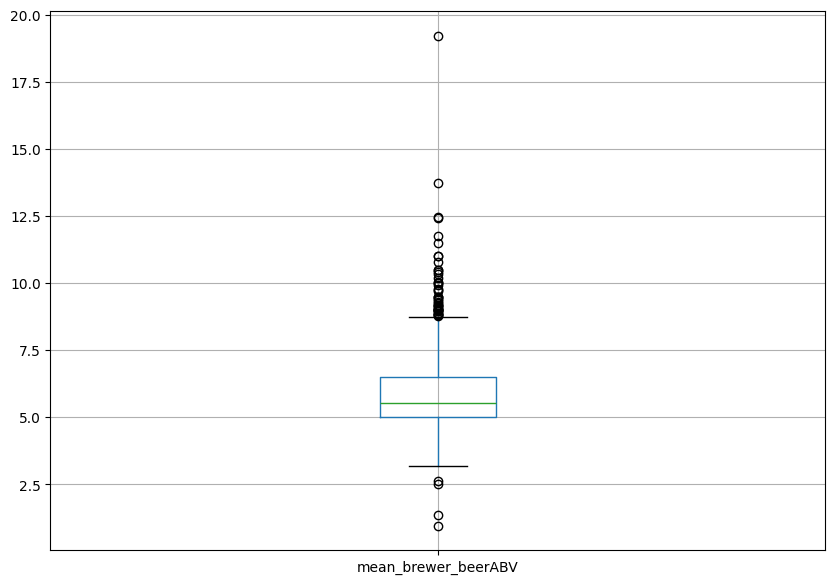

In [12]:
# plot the distribution of the beer ABV that different breweries are making
df_q1_renamed.boxplot(column="mean_brewer_beerABV", figsize=(10,7))
plt.show()

Question 2 Which year did beers enjoy the highest ratings?

In [13]:
# extract year from the review timestamp
df["review_year"] = pd.to_datetime(df["review_time"], unit="s").dt.year

In [16]:
# we want to find the reviews per year to know the sample size for each mean
reviews_per_year = df.groupby(by="review_year").size().to_frame("reviews_per_year").reset_index()
# print a sample
reviews_per_year.sample(n=5, random_state=42)

,review_year,reviews_per_year
9,2007,46514
11,2009,83578
0,1998,23
13,2011,110836
5,2003,18187


In [14]:
df_q2 = df.groupby(by="review_year")["review_overall"].mean().reset_index().sort_values(by="review_overall",
                                                                                        ascending=False)
# again, renaming the column for readability
df_q2 = df_q2.rename(columns={
    "review_overall": "yearly_mean_overall_review"
})
df_q2.sample(n=5, random_state=42)

,review_year,yearly_mean_overall_review
13,2011,3.828093
4,2002,3.798905
2,2000,4.181818
6,2004,3.794630
11,2009,3.864390


In [17]:
# merging the two previous DataFrames
df_q2_merged = df_q2.merge(right=reviews_per_year, how="inner", on="review_year")
df_q2_merged.sample(n=5, random_state=42)

,review_year,yearly_mean_overall_review,reviews_per_year
9,2011,3.828093,110836
11,2002,3.798905,7581
0,2000,4.181818,33
13,2004,3.794630,22905
5,2009,3.864390,83578


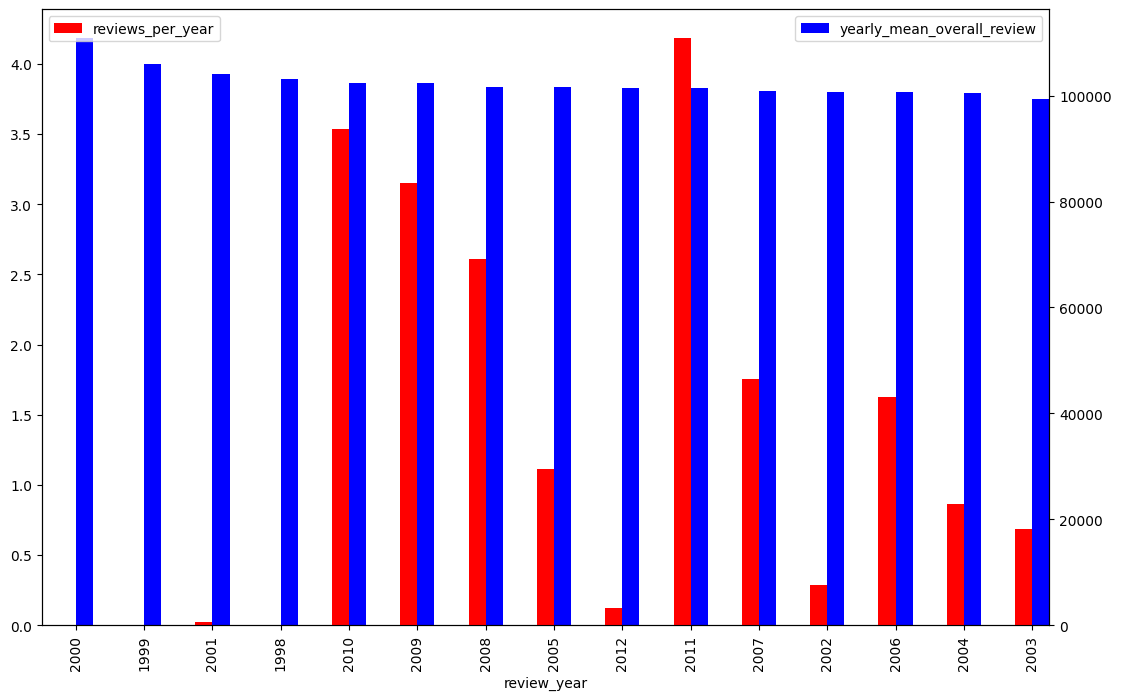

In [18]:
# 2010 is the year with the highest rating since it has the highest rating while having large sample size
figure = plt.figure(figsize=(13, 8))
ax1 = figure.add_subplot(111)
ax2 = ax1.twinx()
df_q2_merged.plot(x="review_year", y="yearly_mean_overall_review", kind="bar", color="blue", ax=ax1, width=0.25, position=0)
df_q2_merged.plot(x="review_year", y="reviews_per_year", kind="bar", color="red", ax=ax2, width=0.25, position=1)
plt.legend(loc="upper left")
plt.show()

Question 3 Based on the users' ratings, which factors are important among taste, aroma, appearance, and palette?

In [19]:
# there are multiple reviews per beer so we aggregate the reviews
df_q3 = df.groupby(by="beer_beerId")[[
    "review_taste",
    "review_aroma",
    "review_appearance",
    "review_palette",
    "review_overall"
]].mean()

In [21]:
# According to the cell output, the aroma is the most important factor for the beer, having a 0.88 correlation with the overall review grade
df_q3.corr()

,review_taste,review_aroma,review_appearance,review_palette,review_overall
review_taste,1.000000,0.821956,0.659598,0.736896,0.809601
review_aroma,0.821956,1.000000,0.637400,0.813106,0.873737
review_appearance,0.659598,0.637400,1.000000,0.647649,0.614839
review_palette,0.736896,0.813106,0.647649,1.000000,0.747198
review_overall,0.809601,0.873737,0.614839,0.747198,1.000000


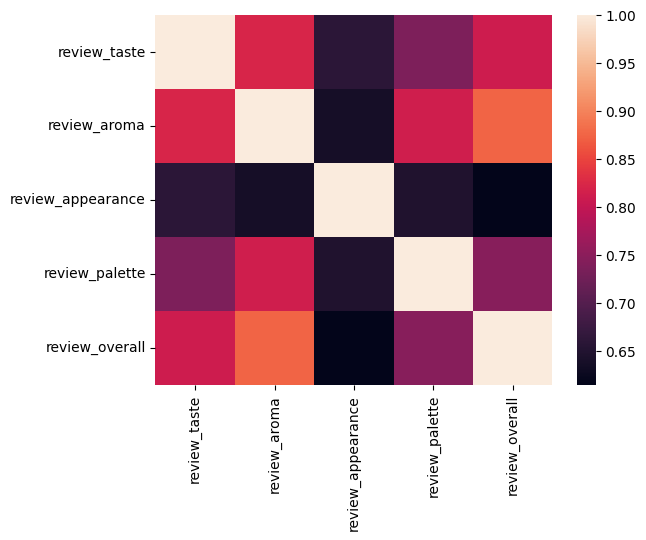

In [22]:
from seaborn import heatmap
heatmap(data=df_q3.corr())
plt.show()

Question 4 If you were to recommend 3 beers to your friends based on this data, which ones would you recommend?

In [29]:
# We would like to recommend them the ones that are reviewed most often, and most highly.
# apply count and mean aggregation functions to review_overall column after grouping by beer_beerId
df_q4 = df.groupby(by="beer_beerId")["review_overall"].agg(["count", "mean"])
# once again, renaming for readability
df_q4 = df_q4.rename(columns={
    "count": "num_reviews",
    "mean": "mean_overall_review"
})

In [28]:
df_q4.sort_values(by="mean_overall_review", ascending=False, inplace=True)
df_q4.head(n=10)

,num_reviews,mean_overall_review
beer_beerId,,
31886,1,5.0
52107,2,5.0
61988,1,5.0
61676,1,5.0
72118,1,5.0
35978,1,5.0
72007,1,5.0
71856,1,5.0
40448,1,5.0


In [26]:
# the distribution for num_reviews is highly right skewed with over 50% having less than 3 reviews
df_q4.describe()

,num_reviews,mean_overall_review
count,20200.000000,20200.000000
mean,26.181683,3.651862
std,123.799950,0.631129
min,1.000000,1.000000
25%,1.000000,3.399774
50%,2.000000,3.750000
75%,7.000000,4.000000
max,3000.000000,5.000000


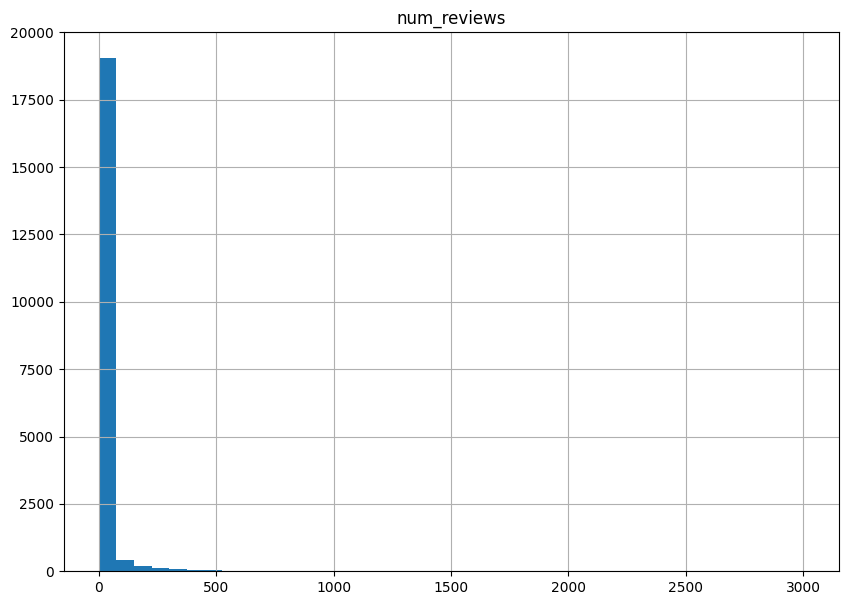

In [30]:
df_q4.hist(column="num_reviews", bins=40, figsize=(10, 7))
plt.show()

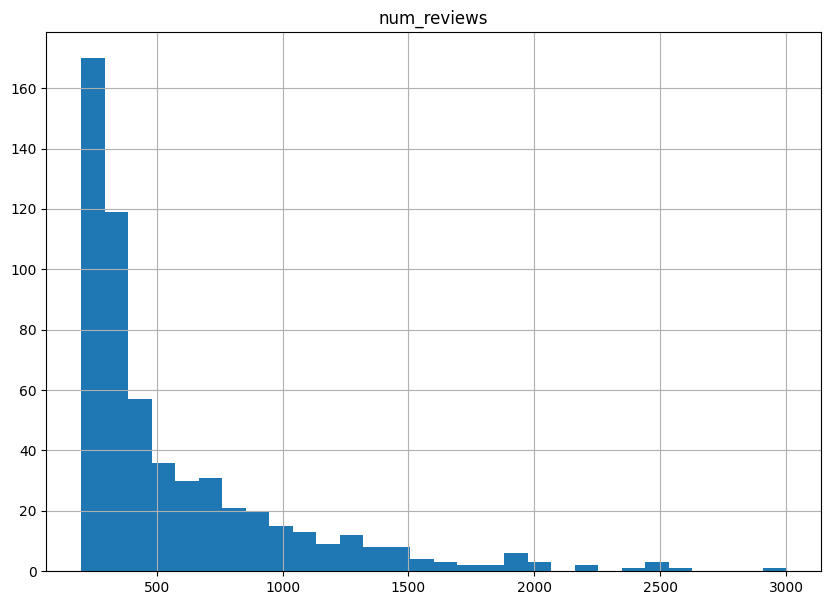

In [31]:
# plotting the distribution again
# we choose 200 as a cut off
df_q4[df_q4["num_reviews"] > 200].hist(column="num_reviews", bins=30, figsize=(10, 7))
plt.show()

In [32]:
# printing the head of the DataFrame, to get the top beer IDs
df_q4[df_q4["num_reviews"] > 200].head()

,num_reviews,mean_overall_review
beer_beerId,,
5,424,3.549528
6,877,3.706956
7,659,3.266313
30,1736,4.113191
31,941,3.971307


In [33]:
df[(df["beer_beerId"] == 56082) | (df["beer_beerId"] == 47658) | (df["beer_beerId"] == 16814)].drop_duplicates(
    subset="beer_beerId")

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time,review_year
16176,10.6,47658,1199,Founders CBS Imperial Stout,American Double / Imperial Stout,4.5,4.5,4.5,5.0,ColForbinBC,4.5,750mL bottle poured into a snifter Pours an in...,1321818225,2011
334853,8.0,56082,14064,Citra DIPA,American Double / Imperial IPA,4.0,4.5,4.5,4.0,IdrinkGas,4.5,Poured from a bomber into a Lost Abbey tulip. ...,1314513820,2011
378400,8.0,16814,27039,Heady Topper,American Double / Imperial IPA,4.5,5.0,4.5,4.5,onefmatt,4.5,"A+ in my book, just a fantastic and well round...",1321078004,2011


Question 5 Which beer style seems to be the favourite based on the reviews written by users? How does written reviews compare to overall review score for that beer style?

In [35]:
# We will use VADER to calculate the sentiment score of text reviews
from nltk import download
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [36]:
download("vader_lexicon", quiet=True)
analyser = SentimentIntensityAnalyzer()

In [37]:
df["review_sentiment"] = df["review_text"].fillna("").apply(
    lambda x: analyser.polarity_scores(str(x))["compound"]
)

In [38]:
df.groupby(by="beer_style")["review_sentiment"].agg(func=["mean", "count"]).sort_values(by="mean", ascending=False)

,mean,count
beer_style,,
Quadrupel (Quad),0.857713,4934
Dortmunder / Export Lager,0.852428,1809
Braggot,0.850789,199
Flanders Red Ale,0.848850,2858
American Double / Imperial Stout,0.847725,23354
...,...,...
Happoshu,0.533456,55
American Malt Liquor,0.523922,1411
Japanese Rice Lager,0.519356,496


In [39]:
df_q5 = df[df["beer_style"] == "Quadrupel (Quad)"]
df_q5[["review_sentiment", "review_overall"]].corr()

,review_sentiment,review_overall
review_sentiment,1.000000,0.258047
review_overall,0.258047,1.000000


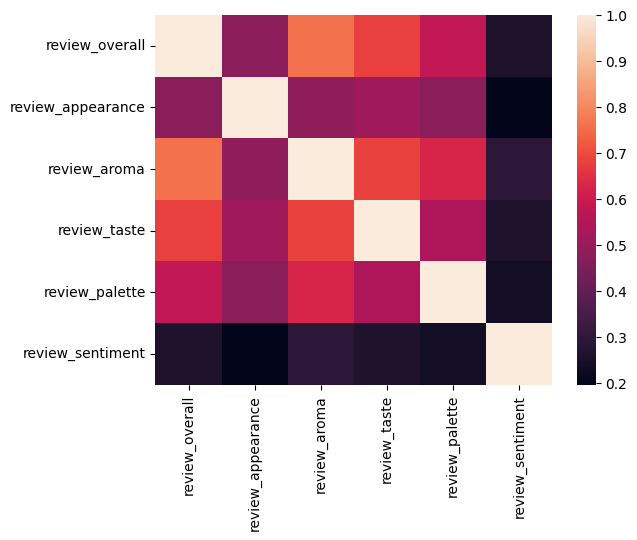

In [42]:
# The coefficient is positive, indicating that increase in the compound score is correlated with an increase in the overall review score.
# The low correlation coefficient might be explained by user leaving generic text review but high score review
heatmap(data=df_q5[[
    "review_overall",
    "review_appearance",
    "review_aroma",
    "review_taste",
    "review_palette",
    "review_sentiment"
]].corr())

plt.show()